In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import f_oneway
from statsmodels.formula.api import ols

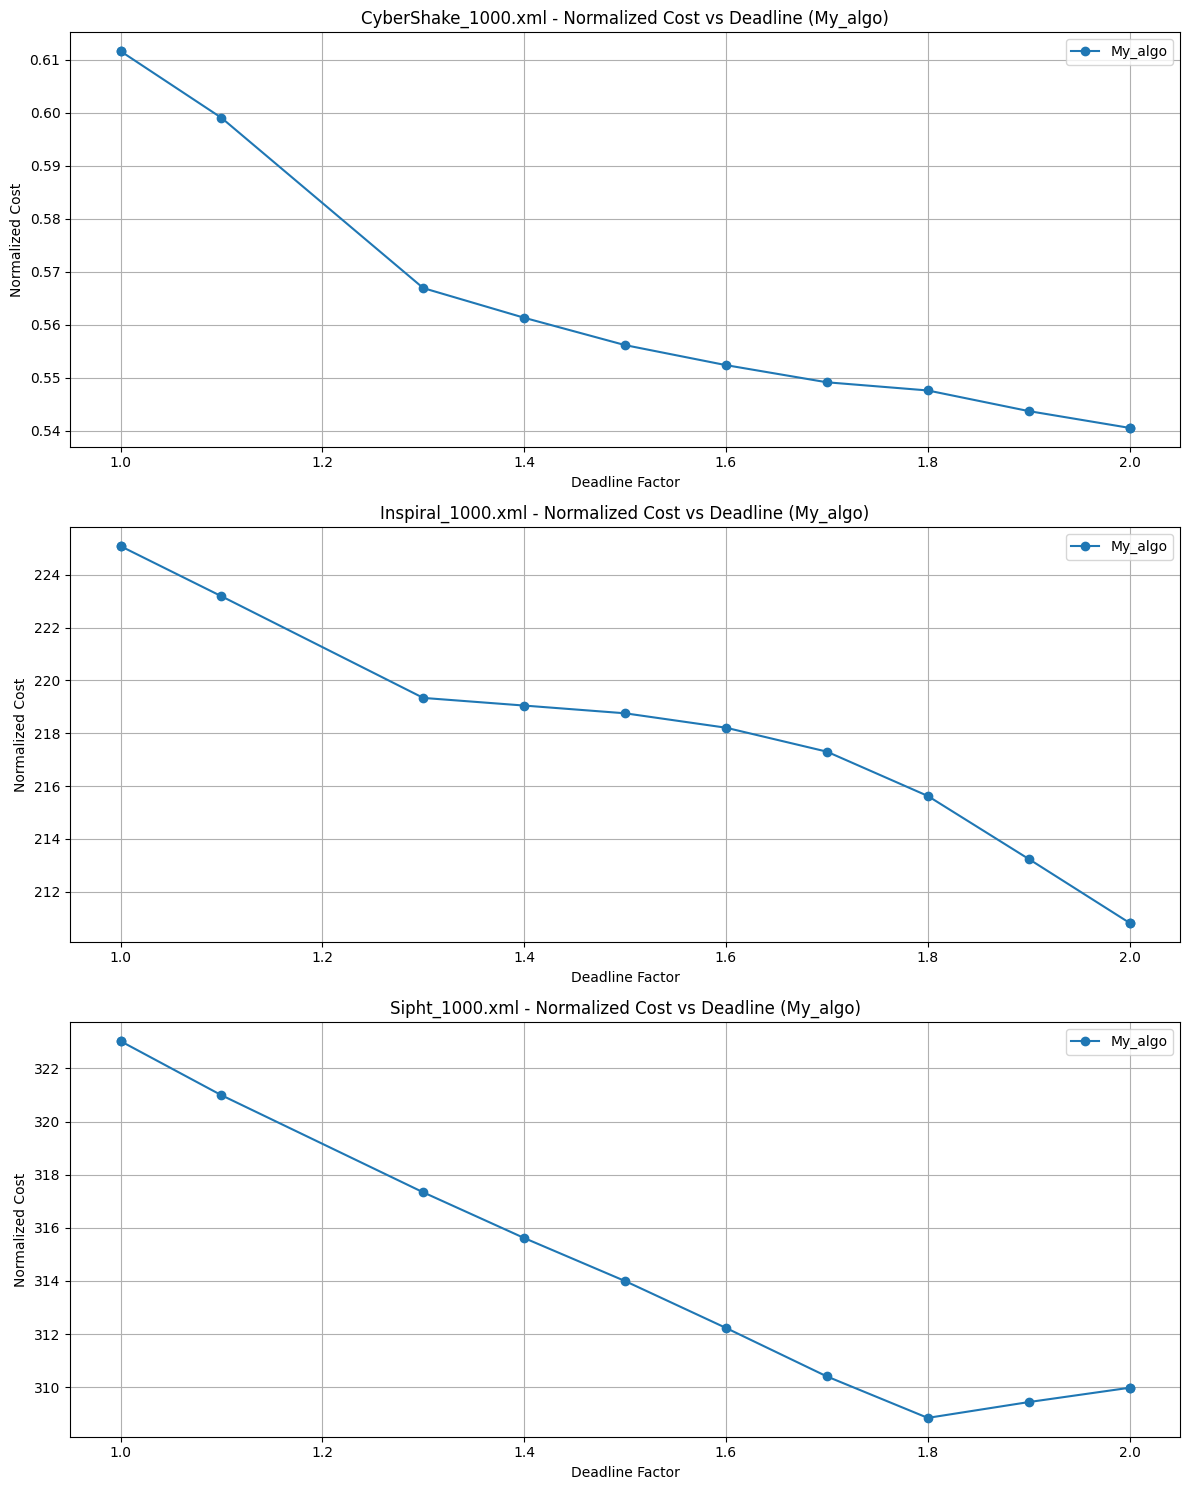

In [13]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-999_1000-Legrage_v1.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

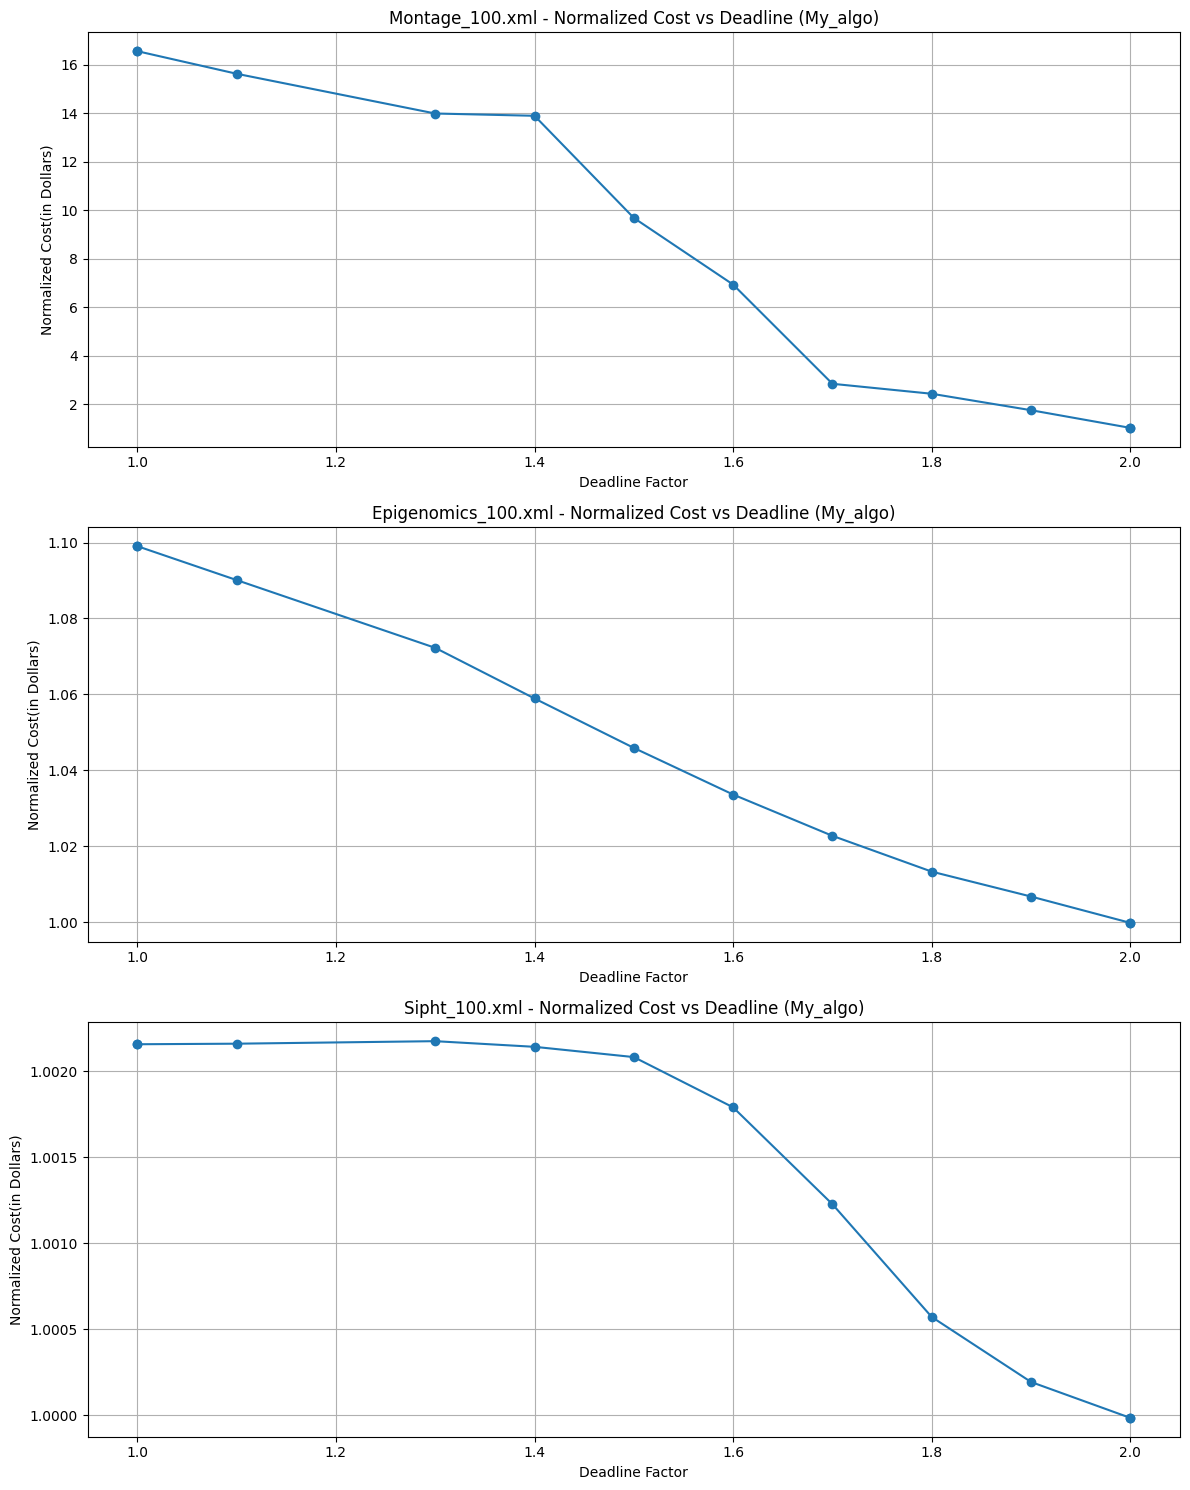

In [12]:
# Read the dataset
df_my = pd.read_csv("999_100_Legrange_v1.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / min_my

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost(in Dollars)")
    ax.grid(True)
    # ax.legend()

plt.tight_layout()
plt.show()

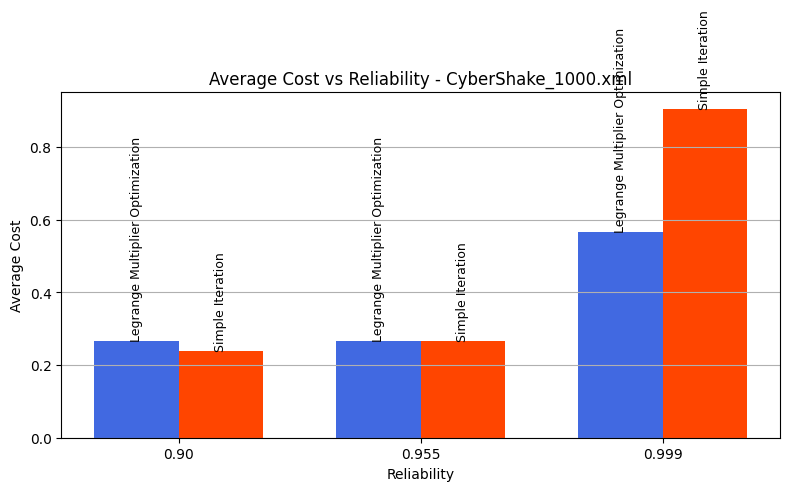

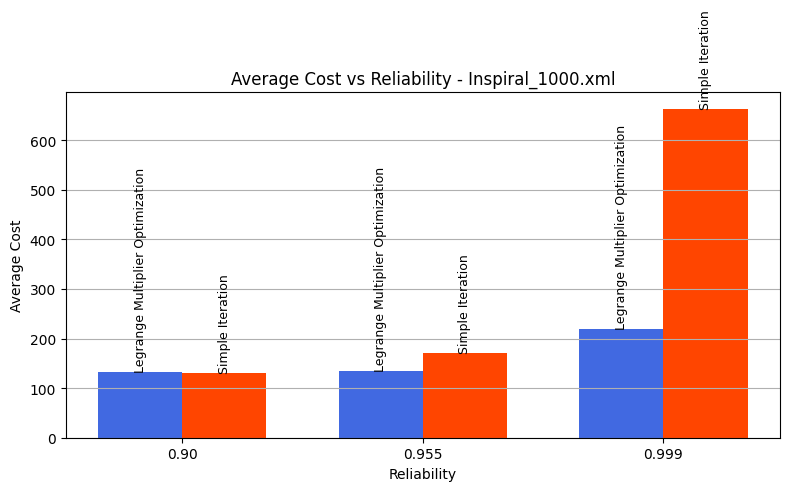

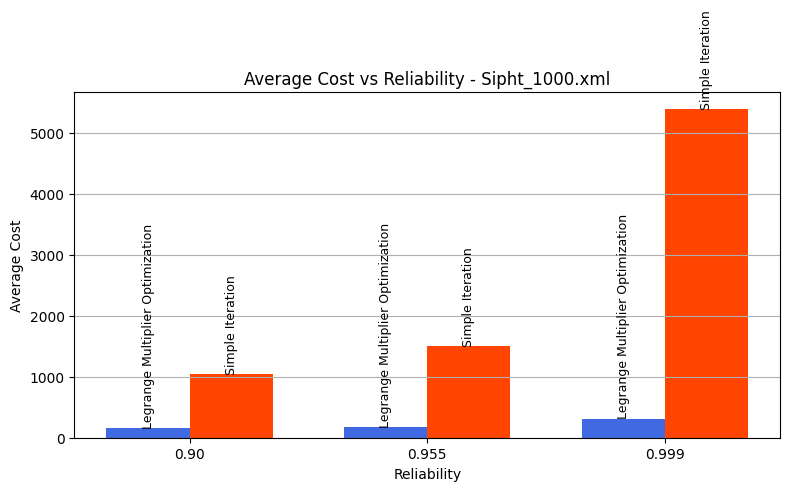

In [ ]:
reliabilities = [900, 955, 999]
methods = ['Legrage', 'woLegrage']

all_data = []

for r in reliabilities:
    for method in methods:
        filename = f"workflow-wise-costs-{r}_1000-{method}_v1.csv"
        df = pd.read_csv(filename)
        df['reliability'] = r
        df['method'] = method
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)

# Average cost per workflow, method, reliability
avg_data = data.groupby(['Workflow', 'method', 'reliability'], as_index=False)['Cost'].mean()

workflows = sorted(avg_data['Workflow'].unique())
x_labels = [0.90, 0.955, 0.999]  # Reliability on x-axis

for workflow in workflows:
    fig, ax = plt.subplots(figsize=(8, 5))
    wf_data = avg_data[avg_data['Workflow'] == workflow]

    x = np.arange(len(reliabilities))  # positions: 0, 1, 2
    bar_width = 0.35

    # Get costs for both methods
    legrage_costs = []
    wo_costs = []
    for r in reliabilities:
        le = wf_data[(wf_data['method'] == 'Legrage') & (wf_data['reliability'] == r)]
        wo = wf_data[(wf_data['method'] == 'woLegrage') & (wf_data['reliability'] == r)]
        legrage_costs.append(le['Cost'].values[0] if not le.empty else 0)
        wo_costs.append(wo['Cost'].values[0] if not wo.empty else 0)

    # Plot bars
    le_bars = ax.bar(x - bar_width/2, legrage_costs, bar_width, label='Legrage', color='royalblue')
    wo_bars = ax.bar(x + bar_width/2, wo_costs, bar_width, label='woLegrage', color='orangered')

    # Annotate bars with method name
    for bar, label in zip(le_bars, ['Legrage'] * 3):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), "Legrange Multiplier Optimization",
                ha='center', va='bottom', fontsize=9, rotation=90)

    for bar, label in zip(wo_bars, ['woLegrage'] * 3):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), "Simple Iteration",
                ha='center', va='bottom', fontsize=9, rotation=90)

    # Format plot
    ax.set_title(f'Average Cost vs Reliability - {workflow}')
    ax.set_xlabel('Reliability')
    ax.set_ylabel('Average Cost')
    ax.set_xticks(x)
    ax.set_xticklabels(['0.90', '0.955', '0.999'])
    # 3ax.legend()
    ax.grid(axis='y')
    plt.tight_layout()
    plt.show()

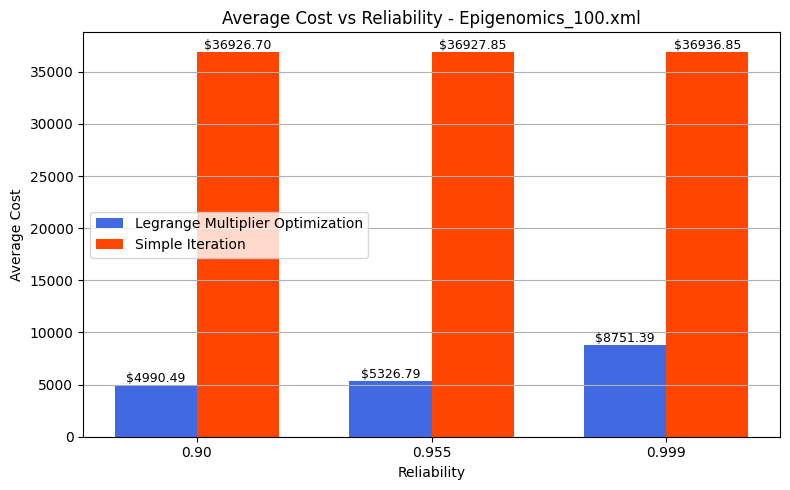

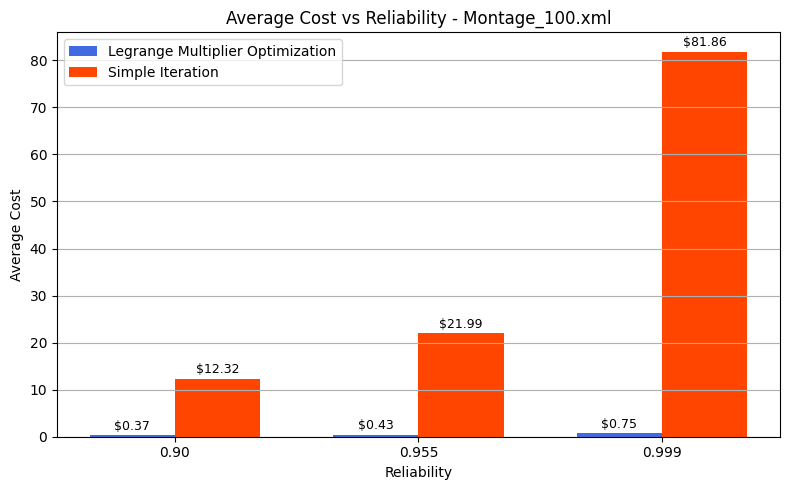

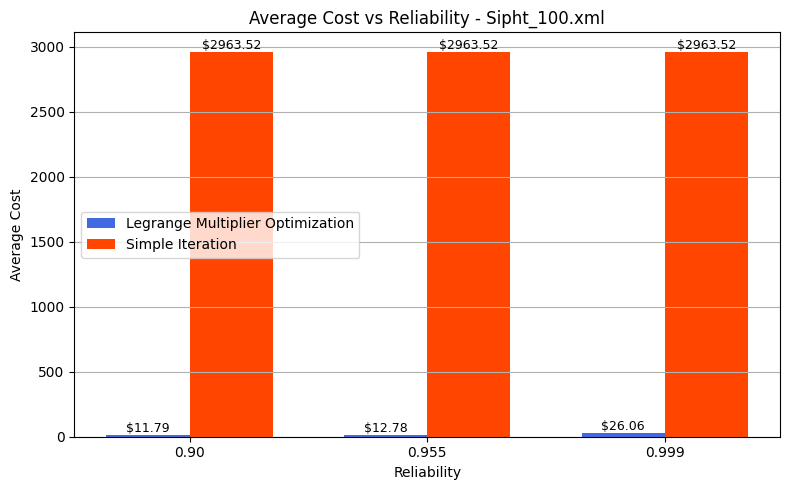

In [47]:
reliabilities = [900, 955, 999]
methods = ['Legrange', 'woLegrange']

all_data = []

for r in reliabilities:
    for method in methods:
        filename = f"{r}_100_{method}_v1.csv"
        df = pd.read_csv(filename)
        df['reliability'] = r
        df['method'] = method
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)

# Average cost per workflow, method, reliability
avg_data = data.groupby(['Workflow', 'method', 'reliability'], as_index=False)['Cost'].mean()

workflows = sorted(avg_data['Workflow'].unique())
x_labels = [0.90, 0.955, 0.999]  # Reliability on x-axis

for workflow in workflows:
    fig, ax = plt.subplots(figsize=(8, 5))
    wf_data = avg_data[avg_data['Workflow'] == workflow]

    x = np.arange(len(reliabilities))  # positions: 0, 1, 2
    bar_width = 0.35

    # Get costs for both methods
    legrage_costs = []
    wo_costs = []
    for r in reliabilities:
        le = wf_data[(wf_data['method'] == 'Legrange') & (wf_data['reliability'] == r)]
        wo = wf_data[(wf_data['method'] == 'woLegrange') & (wf_data['reliability'] == r)]
        legrage_costs.append(le['Cost'].values[0] if not le.empty else 0)
        wo_costs.append(wo['Cost'].values[0] if not wo.empty else 0)

    # Plot bars
    le_bars = ax.bar(x - bar_width/2, legrage_costs, bar_width, label='Legrange Multiplier Optimization', color='royalblue')
    wo_bars = ax.bar(x + bar_width/2, wo_costs, bar_width, label='Simple Iteration', color='orangered')

   # Annotate bars with cost values
    for bar in le_bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"${height:.2f}",
                ha='center', va='bottom', fontsize=9)

    for bar in wo_bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"${height:.2f}",
                ha='center', va='bottom', fontsize=9)


    # Format plot
    ax.set_title(f'Average Cost vs Reliability - {workflow}')
    ax.set_xlabel('Reliability')
    ax.set_ylabel('Average Cost')
    ax.set_xticks(x)
    ax.set_xticklabels(['0.90', '0.955', '0.999'])
    max_cost = max(max(legrage_costs), max(wo_costs))
    # ax.set_ylim(0, max_cost * 1.4)
    ax.legend()
    ax.grid(axis='y')
    plt.tight_layout()
    plt.show()

In [51]:
reliabilities = [900, 955, 999]
methods = ['Legrange', 'woLegrange']

all_data = []

for r in reliabilities:
    for method in methods:
        filename = f"{r}_100_{method}_v1.csv"
        df = pd.read_csv(filename)
        df['reliability'] = r
        df['method'] = method
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)
avg_data = data.groupby(['Workflow', 'method', 'reliability'], as_index=False)['Cost'].mean()


data['reliability'] = data['reliability'].astype(str)  # optional, but helpful

# Define ANOVA model: method + reliability + their interaction
model = ols('Cost ~ C(method) + C(reliability) + C(method):C(reliability)', data=data).fit()

# Perform two-way ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                sum_sq     df          F        PR(>F)
C(method)                 6.757274e+09    1.0  42.552443  5.053043e-10
C(reliability)            1.818905e+07    2.0   0.057271  9.443531e-01
C(method):C(reliability)  1.674566e+07    2.0   0.052726  9.486524e-01
Residual                  3.334774e+10  210.0        NaN           NaN


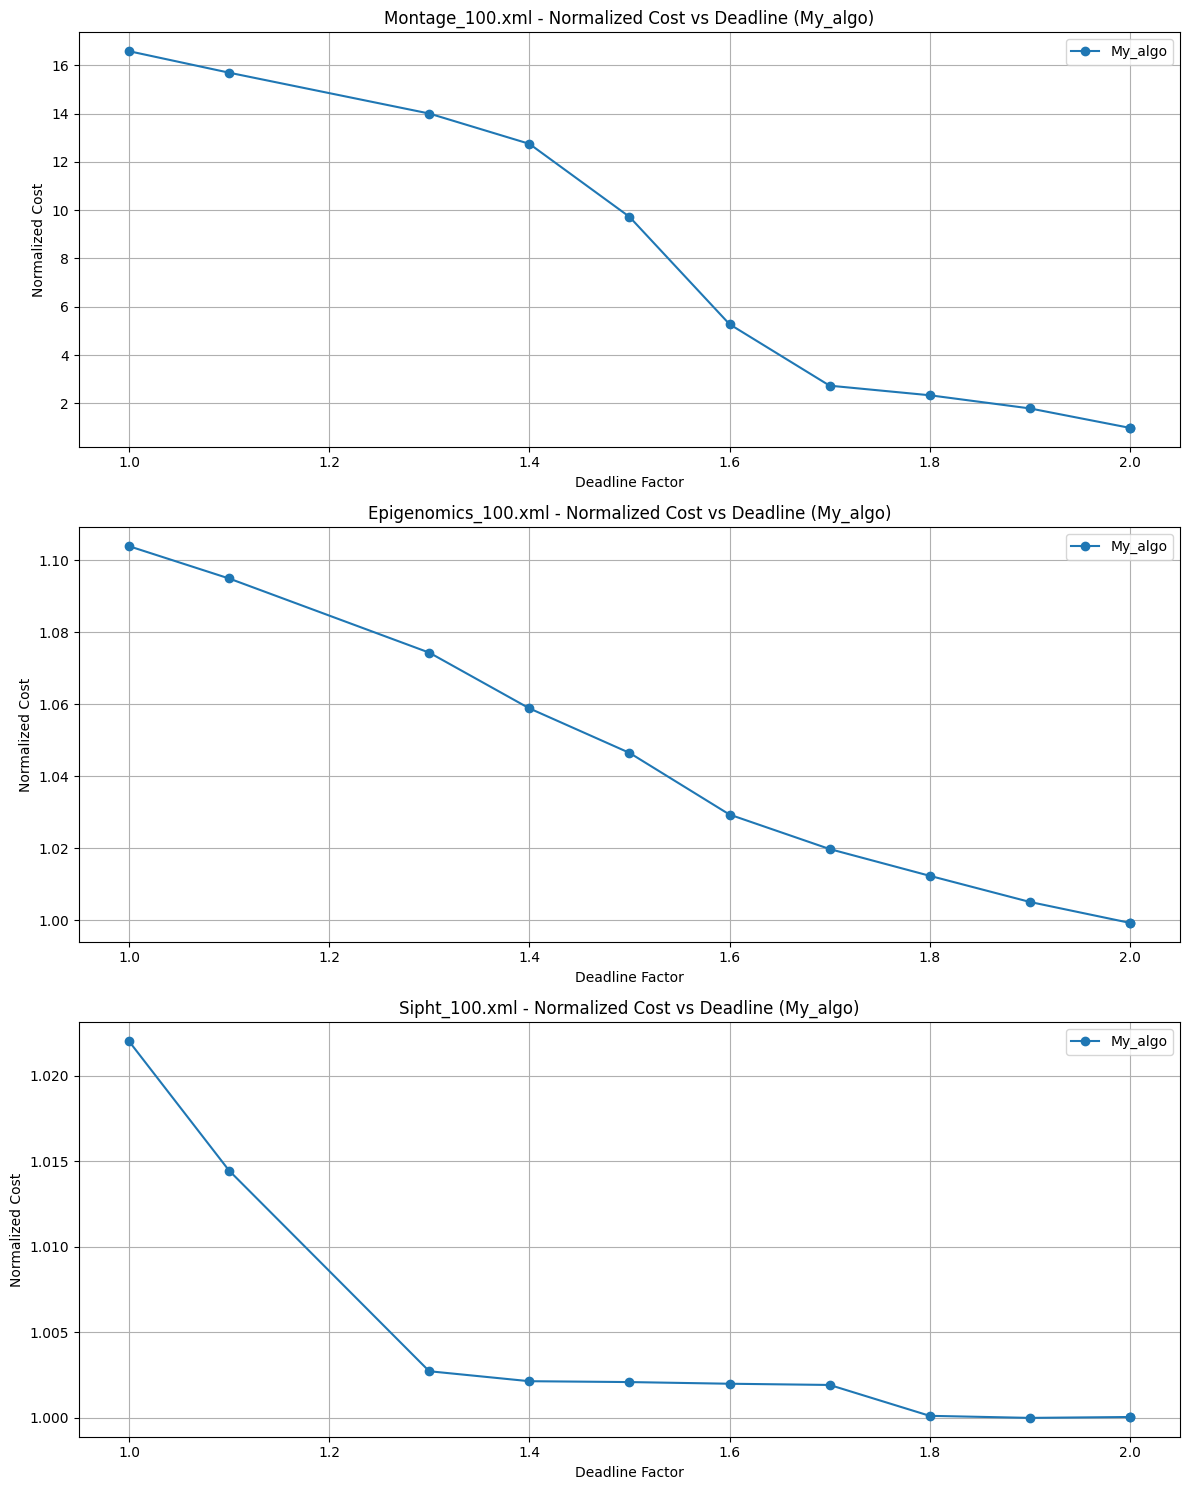

In [12]:
# Read the dataset
df_my = pd.read_csv("workflow_wise_costs_Legrange_v1.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / min_my

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

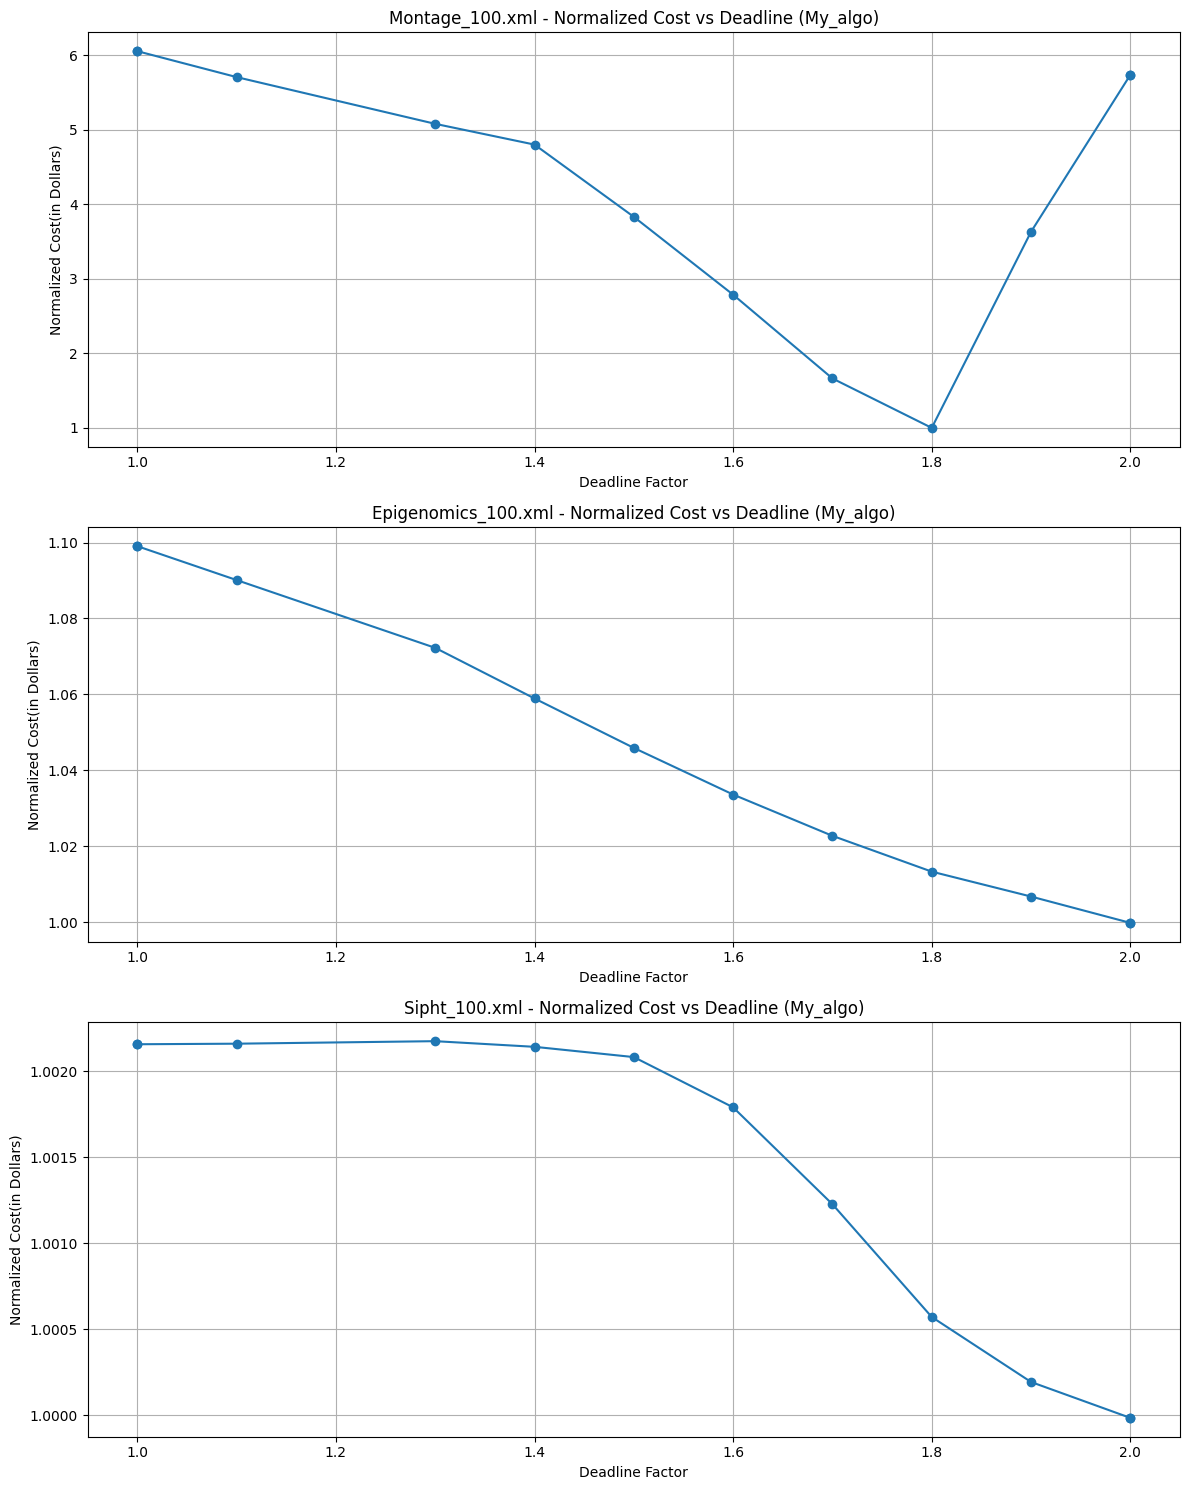

In [5]:
# Read the dataset
df_my = pd.read_csv("Random_Legrange_v1.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / min_my

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost(in Dollars)")
    ax.grid(True)
    # ax.legend()

plt.tight_layout()
plt.show()

In [6]:
df=pd.read_csv("cleaned_vm_data_storage.csv")

In [ ]:
# Clean and convert necessary fields to numeric
df['Instance Storage'] = pd.to_numeric(df['Instance Storage'], errors='coerce')
df['Network Performance'] = pd.to_numeric(df['Network Performance'], errors='coerce')

# If you have a 'MIPS' column, include it directly. If not, derive it manually if possible.
# For now assuming you already have it:
df['MIPS'] = df['vCPUs']*1000*2.5

# Compute medians
median_storage = df['Instance Storage'].mean()
median_network = df['Network Performance'].mean()
median_mips = df['MIPS'].mean() if 'MIPS' in df.columns else None

# Display results
print("Median Storage (GB):", median_storage)
print("Median Network Performance (MBps):", median_network)
print("Median MIPS:", median_mips)

Median Storage (GB): 3331.944856839873
Median Network Performance (MBps): 25.0
Median MIPS: 80000.0
